In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
from tqdm.notebook import tqdm
import h5py
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
import torch.onnx

In [ ]:
# Path where your 'data/data' folder lives locally in Colab
base_dir = Path("/content/drive/MyDrive/Colab_Notebooks/Money/Currency/data/data")

# Map denomination string names to clean integer class indices (0 to 6)
DENOM_MAP = {
    "10": 0,
    "20": 1,
    "50": 2,
    "100": 3,
    "200": 4,
    "500": 5,
    "2000": 6
}

records = []

# Iterate through 'real' and 'fake' directories
for auth_str in ["real", "fake"]:
    auth_label = 1.0 if auth_str == "real" else 0.0  # Float for BCEWithLogitsLoss

    for denom_str, denom_idx in DENOM_MAP.items():
        folder_path = base_dir / auth_str / denom_str

        if folder_path.exists():
            # Match all common image extensions
            for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG"]:
                for img_path in folder_path.glob(ext):
                    records.append({
                        "filepath": str(img_path),
                        "denom_label": denom_idx,    # Integer index for CrossEntropyLoss
                        "auth_label": auth_label,    # Float value for Binary Loss
                        "denom_name": denom_str,
                        "auth_name": auth_str
                    })

# Create metadata DataFrame
df = pd.DataFrame(records)

print(f"✅ Total images indexed: {len(df)}")
print("\n--- Denomination Breakdown ---")
print(df["denom_name"].value_counts())
print("\n--- Authenticity Breakdown ---")
print(df["auth_name"].value_counts())

✅ Total images indexed: 7442

--- Denomination Breakdown ---
denom_name
500     1453
10      1250
20      1247
50      1143
100     1106
200      841
2000     402
Name: count, dtype: int64

--- Authenticity Breakdown ---
auth_name
real    4937
fake    2505
Name: count, dtype: int64


In [ ]:
# Define the target size for resizing images
TARGET_SIZE = (256, 256)

# Function to load and resize image
def load_and_resize_image(filepath, target_size):
    img = cv2.imread(filepath) # Read the image
    if img is None:
        return None # Handle cases where image can't be read
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA) # Resize image
    return img

# Create a new column for cached image data
# Use tqdm for a progress bar as this operation can take some time
print(f"Caching {len(df)} images into RAM...")
df['image_array'] = [
    load_and_resize_image(filepath, TARGET_SIZE)
    for filepath in tqdm(df['filepath'], desc="Loading and Resizing Images")
]

# Check for any None values in 'image_array' (indicating failed loads)
failed_loads = df['image_array'].isnull().sum()
if failed_loads > 0:
    print(f"Warning: {failed_loads} images failed to load or were not found.")
    df = df.dropna(subset=['image_array']).reset_index(drop=True)
    print(f"Dropped {failed_loads} rows. New DataFrame size: {len(df)}")

print("Caching complete!")
print("First image array shape:", df['image_array'].iloc[0].shape)
print("Memory usage of image_array column:", df['image_array'].memory_usage(deep=True) / (1024**2), "MB")


Caching 7442 images into RAM...


Loading and Resizing Images:   0%|          | 0/7442 [00:00<?, ?it/s]

Caching complete!
First image array shape: (256, 256, 3)
Memory usage of image_array column: 1396.4539070129395 MB


In [ ]:
df.head()

,filepath,denom_label,auth_label,denom_name,auth_name,image_array
0,/content/drive/MyDrive/Colab_Notebooks/Money/C...,0,1.0,10,real,"[[[4, 0, 0], [2, 1, 0], [2, 1, 0], [1, 1, 1], ..."
1,/content/drive/MyDrive/Colab_Notebooks/Money/C...,0,1.0,10,real,"[[[76, 46, 39], [75, 46, 40], [77, 48, 42], [7..."
2,/content/drive/MyDrive/Colab_Notebooks/Money/C...,0,1.0,10,real,"[[[207, 207, 207], [255, 255, 255], [254, 254,..."
3,/content/drive/MyDrive/Colab_Notebooks/Money/C...,0,1.0,10,real,"[[[54, 48, 33], [71, 71, 56], [24, 23, 13], [5..."
4,/content/drive/MyDrive/Colab_Notebooks/Money/C...,0,1.0,10,real,"[[[92, 111, 117], [87, 109, 109], [86, 109, 10..."


In [ ]:
df.to_csv('/content/drive/MyDrive/Colab_Notebooks/Money/Currency/MetaData.csv', index=False)

In [ ]:
# Define the path for the HDF5 file
hdf5_path = '/content/drive/MyDrive/Colab_Notebooks/Money/Currency/MetaData.h5'

# Save the DataFrame to HDF5
df.to_hdf(hdf5_path, key='df', mode='w')

print(f"DataFrame saved to {hdf5_path} using HDF5 format.")

Now, to demonstrate that loading from HDF5 preserves the `image_array` column, let's load it into a new DataFrame and check the data type of the `image_array`.

In [ ]:
# Load the DataFrame from HDF5
df_loaded = pd.read_hdf('/content/drive/MyDrive/Colab_Notebooks/Money/Currency/MetaData.h5', key='df')

print("DataFrame loaded from HDF5. Checking the first few rows:")
display(df_loaded.head())

print("\nChecking the type of the first element in 'image_array' column:")
print(type(df_loaded['image_array'].iloc[0]))
print("Shape of the first image array:", df_loaded['image_array'].iloc[0].shape)

array([[[  4,   0,   0],
        [  2,   1,   0],
        [  2,   1,   0],
        ...,
        [141, 157, 154],
        [142, 157, 157],
        [143, 157, 158]],

       [[  2,   0,   0],
        [  2,   1,   0],
        [  2,   1,   0],
        ...,
        [141, 157, 154],
        [142, 157, 157],
        [143, 157, 158]],

       [[  1,   0,   0],
        [  1,   0,   0],
        [  4,   0,   0],
        ...,
        [141, 157, 154],
        [142, 157, 157],
        [143, 157, 158]],

       ...,

       [[ 45,  32,  13],
        [ 36,  27,   6],
        [ 40,  30,  10],
        ...,
        [105, 114, 115],
        [101, 112, 114],
        [ 99, 111, 113]],

       [[ 47,  32,  13],
        [ 39,  27,   7],
        [ 44,  29,  10],
        ...,
        [105, 112, 114],
        [101, 111, 113],
        [ 98, 111, 112]],

       [[ 48,  32,  13],
        [ 41,  27,   8],
        [ 46,  28,  10],
        ...,
        [105, 110, 113],
        [101, 110, 112],
        [ 97, 110, 112]]], dtype=uint8)
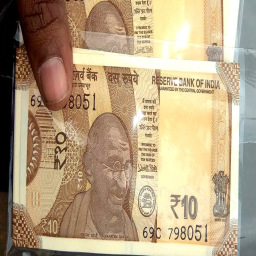

In [ ]:
df_loaded['image_array'][0]

In [ ]:
# Ensure the DataFrame 'df' is loaded from HDF5 for further operations
# Assuming hdf5_path is still defined from the previous steps
hdf5_path = '/content/drive/MyDrive/Colab_Notebooks/Money/Currency/MetaData.h5'
df = pd.read_hdf(hdf5_path, key='df')

print("DataFrame loaded from HDF5 for splitting.")

# 1. Create composite column for joint stratification
df['strat_key'] = df['auth_label'].astype(str) + "_" + df['denom_label'].astype(str)

# 2. Split into Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df['strat_key']
)

# 3. Split Temp into Val (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['strat_key']
)

print(f"\nTrain samples: {len(train_df)} | Val samples: {len(val_df)} | Test samples: {len(test_df)}")

DataFrame loaded from HDF5 for splitting.

Train samples: 5209 | Val samples: 1116 | Test samples: 1117


You now have `train_df`, `val_df`, and `test_df` DataFrames, with the `image_array` column (containing the pre-loaded image data) and stratified splits to maintain class distributions.

In [ ]:
# ImageNet normalization statistics
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(256, 256),
    A.RandomCrop(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=15, p=0.5),
    A.CoarseDropout(max_holes=6, max_height=24, max_width=24, p=0.4), # Simulates finger occlusion
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])

print("Albumentations `train_transform` and `val_transform` defined.")

Albumentations `train_transform` and `val_transform` defined.


/tmp/ipykernel_488/3905848116.py:11: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, max_height=24, max_width=24, p=0.4), # Simulates finger occlusion


In [ ]:
class DualTaskCurrencyDataset(Dataset):
    def __init__(self, df, transform=None):
        # Resetting the index is crucial! train_test_split scrambles indices.
        # PyTorch needs them to start from 0 and go to len(df) sequentially.
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1. Pull the pre-loaded numpy image directly from the HDF5 row
        image = row['image_array']

        # 2. Apply Albumentations transformations
        if self.transform:
            # Albumentations expects HWC format and then converts to CHW if ToTensorV2 is used
            augmented = self.transform(image=image)
            image = augmented['image']

        # 3. Extract and format targets for Multi-Task Loss
        denom_label = torch.tensor(row['denom_label'], dtype=torch.long)    # Categorical classification
        auth_label  = torch.tensor(row['auth_label'], dtype=torch.float32)  # Binary classification

        return image, denom_label, auth_label

print("✅ `DualTaskCurrencyDataset` class defined.")

✅ `DualTaskCurrencyDataset` class defined.


In [ ]:
# Train gets the chaotic, random transformations
train_dataset = DualTaskCurrencyDataset(train_df, transform=train_transform)

# BOTH Val and Test get the strict, deterministic resizing
val_dataset   = DualTaskCurrencyDataset(val_df, transform=val_transform)
test_dataset  = DualTaskCurrencyDataset(test_df, transform=val_transform)

print("✅ PyTorch Datasets successfully instantiated.")

✅ PyTorch Datasets successfully instantiated.


In [ ]:
BATCH_SIZE = 32

# Only the train_loader gets shuffled!
# We keep val and test sequential for accurate metric calculation later.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# --- Sanity Check ---
# Let's pull one single batch from the train_loader to ensure the pipeline flows
images, denoms, auths = next(iter(train_loader))

print("\n--- Pipeline Sanity Check ---")
print(f"Batch Image Shape:  {images.shape}")   # Expected: [32, 3, 224, 224]
print(f"Batch Denom Labels: {denoms.shape}")  # Expected: [32]
print(f"Batch Auth Labels:  {auths.shape}")   # Expected: [32]
print(f"Image Data Type:    {images.dtype}")  # Expected: torch.float32


--- Pipeline Sanity Check ---
Batch Image Shape:  torch.Size([32, 3, 224, 224])
Batch Denom Labels: torch.Size([32])
Batch Auth Labels:  torch.Size([32])
Image Data Type:    torch.float32


### The Multi-Task Neural Network
We will use EfficientNet-B3 as the shared feature extractor because it offers an excellent balance of high accuracy and low parameter count, which is ideal for edge-device deployment. We will strip its default 1,000-class ImageNet head and attach our two custom heads.

In [ ]:
class CurrencyMultiTaskNet(nn.Module):
    def __init__(self, num_denoms=7): # e.g., 10, 20, 50, 100, 200, 500, 2000
        super(CurrencyMultiTaskNet, self).__init__()

        # 1. Load Pretrained Backbone
        weights = EfficientNet_B3_Weights.DEFAULT
        self.backbone = efficientnet_b3(weights=weights)

        # 2. Extract the incoming feature size (1536 for B3)
        in_features = self.backbone.classifier[1].in_features

        # 3. Strip the original ImageNet classifier head
        self.backbone.classifier = nn.Identity()

        # 4. Denomination Head (Categorical)
        self.denom_head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_denoms)
        )

        # 5. Authentication Head (Binary)
        self.auth_head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        # Extract deep features from the shared backbone
        features = self.backbone(x)

        # Route the shared features to both independent heads
        denom_logits = self.denom_head(features)
        auth_logits = self.auth_head(features)

        # Squeeze auth_logits from [batch, 1] to [batch] to align with target tensors
        return denom_logits, auth_logits.squeeze(-1)

### Homoscedastic Uncertainty Loss
When training a multi-task model, one task often dominates the network's gradients and destroys the performance of the other task. Tuning these weights by hand is a difficult and expensive process. To resolve this, we will weigh the loss functions by considering the homoscedastic uncertainty of each task, which allows the model to automatically learn the optimal balance between different classification scales.Instead of dividing by the variance directly (which can cause division-by-zero crashes), we formulate the loss using log-variance ($\eta = \log(\sigma^2)$):$$\mathcal{L}_{total} = e^{-\eta_{denom}} \mathcal{L}_{denom} + \frac{1}{2}\eta_{denom} + e^{-\eta_{auth}} \mathcal{L}_{auth} + \frac{1}{2}\eta_{auth}$$

In [ ]:
class HomoscedasticMultiTaskLoss(nn.Module):
    def __init__(self):
        super(HomoscedasticMultiTaskLoss, self).__init__()

        # Define learnable log-variances (eta) as nn.Parameters
        # Initialized to 0.0 (variance of 1.0)
        self.eta_denom = nn.Parameter(torch.zeros(1))
        self.eta_auth = nn.Parameter(torch.zeros(1))

        # Standard base loss functions
        self.denom_criterion = nn.CrossEntropyLoss()
        self.auth_criterion = nn.BCEWithLogitsLoss()

    def forward(self, denom_preds, denom_targets, auth_preds, auth_targets):
        # 1. Calculate raw base losses
        loss_denom = self.denom_criterion(denom_preds, denom_targets)
        loss_auth = self.auth_criterion(auth_preds, auth_targets)

        # 2. Apply the homoscedastic uncertainty formula
        weighted_loss_denom = torch.exp(-self.eta_denom) * loss_denom + 0.5 * self.eta_denom
        weighted_loss_auth = torch.exp(-self.eta_auth) * loss_auth + 0.5 * self.eta_auth

        # 3. Sum for the final backward pass
        total_loss = weighted_loss_denom + weighted_loss_auth

        return total_loss, loss_denom, loss_auth

### Instantiation and Optimization

In [ ]:
# 1. Push model and loss function to the GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CurrencyMultiTaskNet(num_denoms=7).to(device)
criterion = HomoscedasticMultiTaskLoss().to(device)

# 2. Group all learnable parameters together
# The optimizer needs to update the network weights AND the uncertainty parameters
trainable_params = list(model.parameters()) + list(criterion.parameters())

# 3. Initialize the AdamW optimizer (great for Vision models)
optimizer = torch.optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-4)

print(f"✅ Model loaded on {device}")
print(f"✅ Optimizer tracking {len(trainable_params)} parameter tensors")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:01<00:00, 47.2MB/s]


✅ Model loaded on cuda
✅ Optimizer tracking 348 parameter tensors


### The AMP Training Loop

In [ ]:
# 1. Initialize AMP Scaler and Training Parameters
scaler = GradScaler()
EPOCHS = 15
best_val_loss = float('inf')
save_path = '/content/drive/MyDrive/Colab_Notebooks/Money/Currency/Models/best_multitask_model.pth'

print("🚀 Starting Phase 3: Multi-Task Training with AMP...")

for epoch in range(EPOCHS):
    # ==========================================
    #               TRAINING PHASE
    # ==========================================
    model.train()
    running_train_loss = 0.0

    # tqdm provides a nice progress bar in Colab
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for images, denoms, auths in train_bar:
        # Move data to GPU
        images, denoms, auths = images.to(device), denoms.to(device), auths.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Enable AMP for the forward pass
        with autocast():
            denom_preds, auth_preds = model(images)
            loss, loss_denom, loss_auth = criterion(denom_preds, denoms, auth_preds, auths)

        # Scale the loss and do backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item()
        train_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = running_train_loss / len(train_loader)

    # ==========================================
    #              VALIDATION PHASE
    # ==========================================
    model.eval()
    running_val_loss = 0.0
    denom_correct, auth_correct, total_samples = 0, 0, 0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")

    # Disable gradient tracking for evaluation to save memory
    with torch.no_grad():
        for images, denoms, auths in val_bar:
            images, denoms, auths = images.to(device), denoms.to(device), auths.to(device)

            # Forward pass only (with AMP)
            with autocast():
                denom_preds, auth_preds = model(images)
                loss, _, _ = criterion(denom_preds, denoms, auth_preds, auths)

            running_val_loss += loss.item()

            # --- Calculate Accuracies ---
            # Denomination: Get the index of the highest probability
            denom_preds_classes = torch.argmax(denom_preds, dim=1)
            # Authentication: Apply sigmoid and threshold at 0.5
            auth_preds_classes = (torch.sigmoid(auth_preds) > 0.5).float()

            denom_correct += (denom_preds_classes == denoms).sum().item()
            auth_correct += (auth_preds_classes == auths).sum().item()
            total_samples += denoms.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    denom_acc = denom_correct / total_samples
    auth_acc = auth_correct / total_samples

    # ==========================================
    #              METRICS & CHECKPOINTING
    # ==========================================
    print(f"\n📊 Epoch {epoch+1} Results:")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Val Denom Acc: {denom_acc:.4f} | Val Auth Acc: {auth_acc:.4f}")

    # Save the model only if validation loss improves
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss_params': criterion.state_dict(),  # Save the learned uncertainties!
            'val_loss': avg_val_loss
        }, save_path)
        print(f"🌟 New best model saved to Drive: Validation loss improved to {avg_val_loss:.4f}\n")
    else:
        print("\n")

/tmp/ipykernel_488/1848248987.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🚀 Starting Phase 3: Multi-Task Training with AMP...


Epoch 1/15 [Train]:   0%|          | 0/163 [00:00<?, ?it/s]/tmp/ipykernel_488/1848248987.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/15 [Val]:   0%|          | 0/35 [00:00<?, ?it/s]/tmp/ipykernel_488/1848248987.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/15 [Val]: 100%|██████████| 35/35 [00:06<00:00,  5.11it/s]



📊 Epoch 1 Results:
Train Loss: 1.6188 | Val Loss: 0.6759
Val Denom Acc: 0.8091 | Val Auth Acc: 0.9606
🌟 New best model saved to Drive: Validation loss improved to 0.6759



Epoch 2/15 [Val]: 100%|██████████| 35/35 [00:03<00:00,  9.77it/s]


...


📊 Epoch 13 Results:
Train Loss: -0.1075 | Val Loss: -0.0820
Val Denom Acc: 0.9910 | Val Auth Acc: 0.9928
🌟 New best model saved to Drive: Validation loss improved to -0.0820



Epoch 14/15 [Val]: 100%|██████████| 35/35 [00:02<00:00, 12.39it/s]



📊 Epoch 14 Results:
Train Loss: -0.1435 | Val Loss: -0.0867
Val Denom Acc: 0.9857 | Val Auth Acc: 0.9919
🌟 New best model saved to Drive: Validation loss improved to -0.0867



Epoch 15/15 [Val]: 100%|██████████| 35/35 [00:02<00:00, 12.54it/s]



📊 Epoch 15 Results:
Train Loss: -0.1619 | Val Loss: -0.1041
Val Denom Acc: 0.9884 | Val Auth Acc: 0.9919
🌟 New best model saved to Drive: Validation loss improved to -0.1041



### Edge Optimization (Exporting to ONNX)

In [ ]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 17.6 MB/s eta 0:00:00


In [ ]:
# 1. Force the execution device to CPU for a stable, clean export
device = torch.device("cpu")

# Load the checkpoint, mapping any GPU tensors safely down to the CPU
checkpoint = torch.load(
    "/content/drive/MyDrive/Colab_Notebooks/Money/Currency/Models/best_multitask_model.pth",
    map_location=device
)

# Load the state dictionary and ensure the model itself is on the CPU
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval() # Set to evaluation mode to disable dropout/batchnorm updates

# 2. Create the dummy input and explicitly assign it to the CPU
dummy_input = torch.randn(1, 3, 224, 224, device=device, requires_grad=False)

# 3. Export to ONNX
onnx_file_path = "/content/drive/MyDrive/Colab_Notebooks/Money/Currency/Models/currency_multitask_edge.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_file_path,
    export_params=True,
    opset_version=18,          # Bumped to 18 to support modern EfficientNet operations
    do_constant_folding=True,  # Optimizes constant operations for faster inference
    input_names=['input_image'],
    output_names=['denom_logits', 'auth_logits'],
    dynamic_axes={
        'input_image': {0: 'batch_size'},         # Allow variable batch sizes
        'denom_logits': {0: 'batch_size'},
        'auth_logits': {0: 'batch_size'}
    }
)

print(f"Model successfully exported to {onnx_file_path} 🚀")

/tmp/ipykernel_488/407188063.py:21: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `CurrencyMultiTaskNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CurrencyMultiTaskNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model successfully exported to /content/drive/MyDrive/Colab_Notebooks/Money/Currency/Models/currency_multitask_edge.onnx 🚀
